In [60]:
# Load a feature path
import torch
con_snmf_feature_path = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/imagenet1000/train/concept/combined_concept_raw.pth"
snmf_cifar100_path = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/imagenet1000/train/concept/redefine_activations_text_grounding_combined_concept_l1_regrounded.pth"
def extract_groundings_and_concepts(feature_path):
    # Load the data from the .pth file
    data = torch.load(feature_path, map_location="cpu")
    
    # Extract concepts and groundings
    concepts = data["concepts"]
    groundigs = data["text_grounding"]
    
    # Process groundings
    processed_groundings = []
    for grounding in groundigs:
        unique_groundings = set(g.lower() for g in grounding)
        filtered_groundings = set()
        for g in unique_groundings:
            # Ensure that the filtering logic checks for substring matches correctly
            if not any(g in other and g != other for other in unique_groundings):
                filtered_groundings.add(g)
        # Sort the filtered groundings to ensure consistent order
        processed_groundings.append("_".join(set(filtered_groundings)))
    
    return concepts, processed_groundings

# Example usage
concept_before, groundigs_before = extract_groundings_and_concepts(con_snmf_feature_path)
print("First 10 groundings:", groundigs_before[:500])

concepts_after, groundigs_after = extract_groundings_and_concepts(snmf_cifar100_path)

First 10 groundings: ['liner_inet_iners_inen', 'bike_mountain', 'rate_adle_rad_c', 'ocker_iel_span', 'scale', 'irish_setter', 'crossword_puzzle', 'ux_lex_ext', 'ori_iet_ikel_lor', 'vat_vault', 'flynn_flyer', 'rolley_bus_t', 'ucchini_cucumber', 'monkey_squirrel', 'ott_oter_iller_iler', 'opener_can', 'garbage_trash_truck', 'microphone_phones_scope', 'iffs_cliff_dwelling', 'emas_ena_emia_cinema_ama_emat', 'telescope_radio_antenna', 'opot_apot_ffe_coff', 'min_avan_ivan', 'rea_umber_rellas', 'esk_dog_imo', 'ellery_ary_bakery_tery', 'christmas_stockings', 'fish_gold', 'shop_atto_tobacco', 'opot_amus_hipp_ampus', 'frying_pan', 'rel_rows_bar_rowing', 'mongoose_manganese', 'ardi_bri_iard_reed_ari', 'rule', 'st_bernard_saint', 'bo_thouse_oth_athlete', 'bears_american_black', 'harvest_man_mon', 'oxygen_mask', 'orna_orns_ac_ron', 'mask_gas', 'ulture_v', 'springer_welsh_span', 'feather_athering_boa_athers', 'player_cd', 'sh_salt_akers', 'squash_spaghetti', 'suit', 'disc_brakes_disk_break', 'english

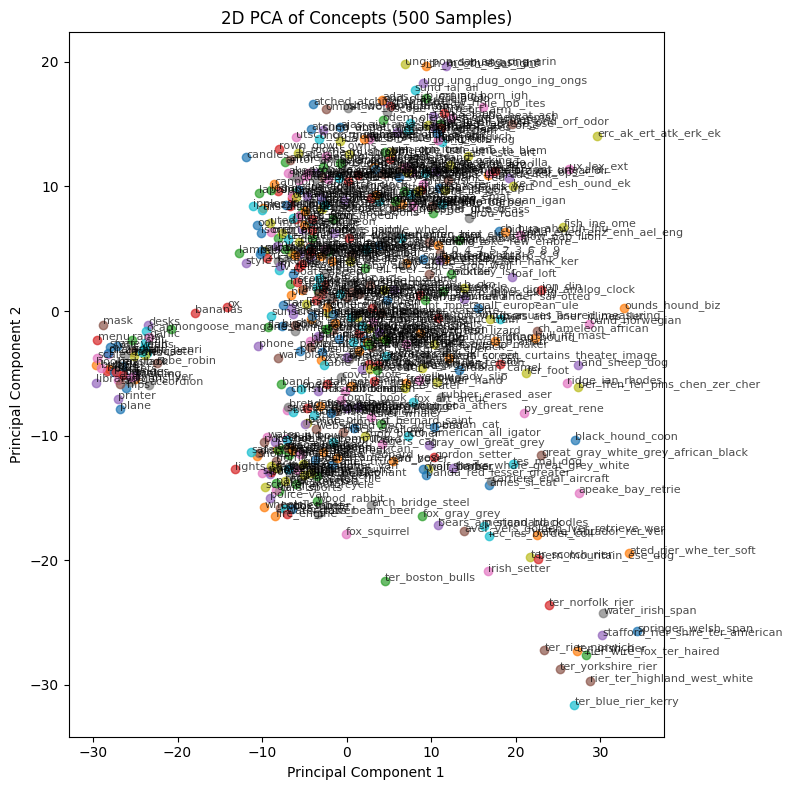

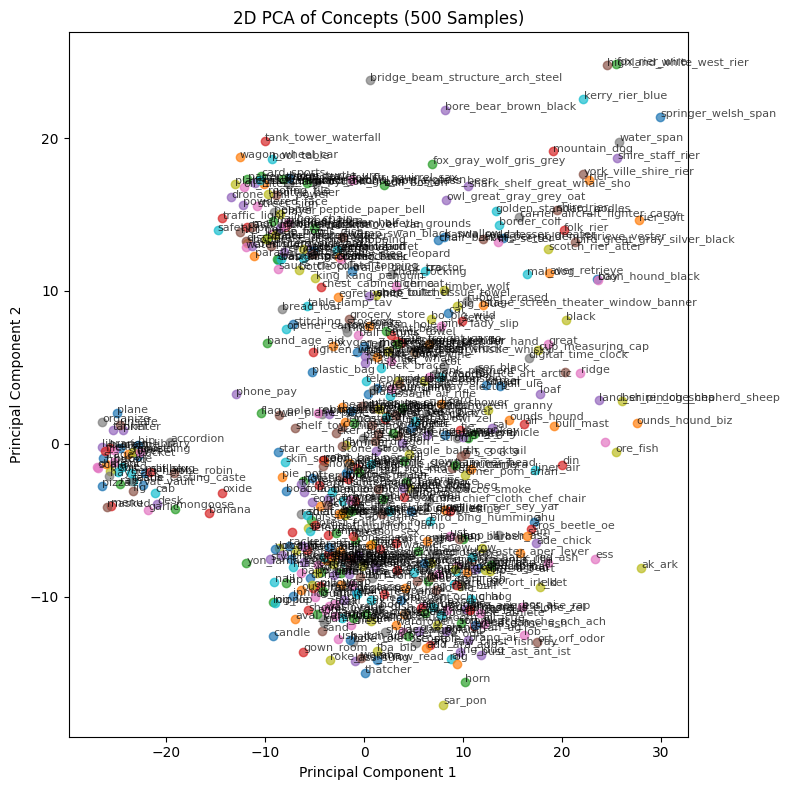

In [61]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def apply_pca_and_save_figure(concepts, groundings, n_samples, output_path, seed=1008, show_labels=True):
    # Set random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)

    # Convert PyTorch tensors to NumPy arrays
    concepts_np = concepts.numpy()

    # Scale the concepts
    scaler = StandardScaler()
    scaled_concepts = scaler.fit_transform(concepts_np)

    # Select random samples
    sample_indices = random.sample(range(len(scaled_concepts)), n_samples)
    sample_concepts = scaled_concepts[sample_indices]
    sample_groundings = [groundings[i] for i in sample_indices]

    # Reduce dimensionality to 2D using PCA
    pca = PCA(n_components=2)
    sample_concepts_2d = pca.fit_transform(sample_concepts)

    # --- Create Figure ---
    plt.figure(figsize=(8, 8))
    for i, (x, y) in enumerate(sample_concepts_2d):
        plt.scatter(x, y, alpha=0.7)
        if show_labels:
            plt.text(x + 0.02, y + 0.02, str(sample_groundings[i]), fontsize=8, alpha=0.7)

    plt.title(f"2D PCA of Concepts ({n_samples} Samples)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    # Save to file
    plt.tight_layout()
    plt.show()
    plt.savefig(output_path, dpi=300)
    plt.close()

# Example usage
apply_pca_and_save_figure(concept_before, groundigs_before, 500,
    "/mnt/abka03/Projects/xl-vlms/plots/mcox/concept_pca/pca_scatter_plot_before.png")

apply_pca_and_save_figure(concepts_after, groundigs_after, 500,
    "/mnt/abka03/Projects/xl-vlms/plots/mcox/concept_pca/pca_scatter_plot_after.png")


In [4]:
feature_path = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/layer_norm_imagenet32/train/concept/combined_concept_raw.pth"
data = torch.load(feature_path, map_location="cpu")

X_lap = data["concepts"]
names = data["text_grounding"]

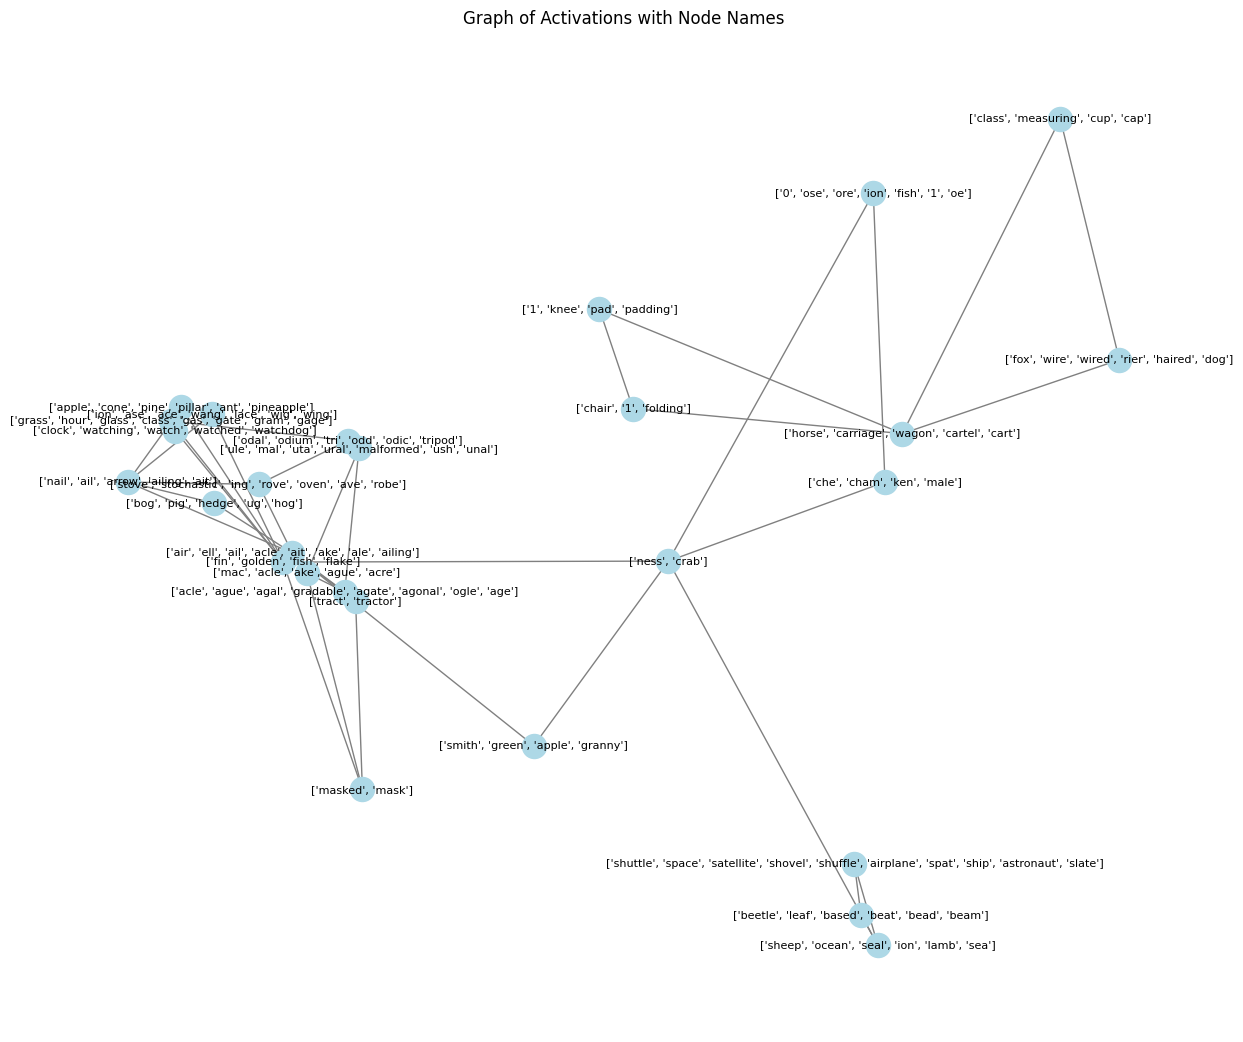

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import kneighbors_graph
from sklearn.decomposition import PCA

# Example inputs (replace with your own)
# X_lap = np.random.rand(100, 10)
# names = [f"node_{i}" for i in range(100)]  # or your actual labels/names

# Step 1: Build the k-NN graph
knn_graph = kneighbors_graph(X_lap, n_neighbors=2, mode='connectivity', include_self=False)
adj_matrix = knn_graph.toarray()
G = nx.from_numpy_array(adj_matrix)

# Step 2: Layout positions (PCA to 2D)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_lap)
pos = {i: X_2d[i] for i in range(len(X_2d))}

# Step 3: Plot the graph with names
plt.figure(figsize=(12, 10))
nx.draw(G, pos, node_size=300, node_color='lightblue', edge_color='gray', with_labels=False)

# Add labels manually
for i, name in enumerate(names):
    x, y = pos[i]
    plt.text(x, y, name, fontsize=8, ha='center', va='center', color='black')

plt.title("Graph of Activations with Node Names")
plt.axis('off')
plt.show()


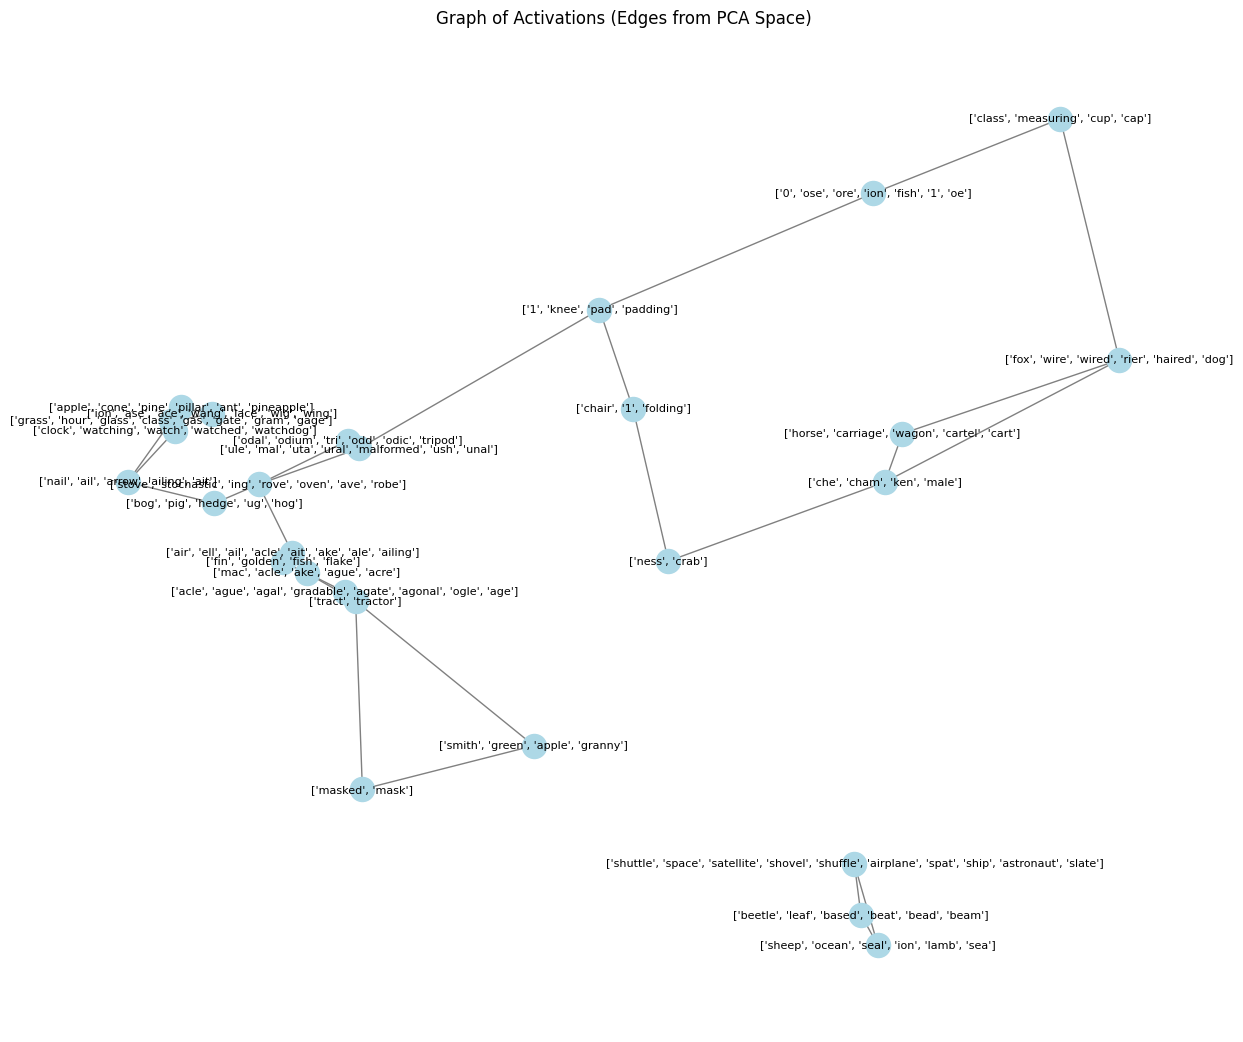

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph

# Inputs:
# X_lap: activation matrix after Laplacian or raw activations
# names: list of node names, length = X_lap.shape[0]

# Step 1: Reduce to 2D with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_lap)

# Step 2: Use distances in PCA space to define edges
# We'll use k-NN here *in PCA space*
knn_graph = kneighbors_graph(X_pca, n_neighbors=2, mode='connectivity', include_self=False)
adj_matrix = knn_graph.toarray()

# Step 3: Create graph
G = nx.from_numpy_array(adj_matrix)
pos = {i: X_pca[i] for i in range(len(X_pca))}  # PCA positions for plotting

# Step 4: Plot
plt.figure(figsize=(12, 10))
nx.draw(G, pos, node_size=300, node_color='lightblue', edge_color='gray', with_labels=False)

# Draw labels (names)
for i, name in enumerate(names):
    x, y = pos[i]
    plt.text(x, y, name, fontsize=8, ha='center', va='center', color='black')

plt.title("Graph of Activations (Edges from PCA Space)")
plt.axis('off')
plt.show()
